In [1]:
# Usual imports
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import Subset
import torchvision.datasets as datasets
from rich.progress import Progress
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

# RobustBench
import robustbench
from robustbench.utils import load_model
from secml.utils import fm
from secml import settings

## CUDA

In [2]:
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA available: True
GPU name: NVIDIA GeForce RTX 4090


## UTILITIES

In [3]:
class ProbRegressionWrapper(nn.Module):
    def __init__(self, classifier):
        super().__init__()
        self.classifier = classifier  # pretrained classifier

    def forward(self, x):
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=1)
        return probs

In [5]:
def load_imagenet_splits(
    root="/path/to/imagenet",
    n_subset = 10000,
    n_train=2000,
    n_cal=1000,
    n_test=2000,
    seed=0
):
    """
    Carica piccoli split da ImageNet (train/cal/test) in memoria,
    coerente con CIFAR10/CIFAR100.

    - restiutisce tensori X_train, y_train, X_cal, y_cal, X_test, y_test
    - immagini normalizzate in [0,1]
    """
    transform = T.Compose([
            T.Resize(256),
            T.CenterCrop(224),   # standard for ImageNet models
            T.ToTensor()
        ])

    full_dataset = datasets.ImageFolder(root=imagenet_path, transform=transform)

    indices = random.sample(range(len(full_dataset)), n_subset)
    subset_dataset = Subset(full_dataset, indices)

    rnd_idx = torch.randperm(len(subset_dataset))
    train_idx = rnd_idx[:n_train]
    cal_idx   = rnd_idx[n_train:n_train + n_cal]
    test_idx  = rnd_idx[n_train + n_cal : n_train + n_cal + n_test]

    # ------------------------
    # Convertiamo tutto in tensori (X,y)
    # ------------------------
    def extract_X_y(dataset, idxs):
        X = []
        y = []
        for i in idxs:
            img, label = dataset[i]
            X.append(img.unsqueeze(0))   # (1,3,224,224)
            y.append(label)
        X = torch.cat(X, dim=0)
        y = torch.tensor(y, dtype=torch.long)
        return X, y

    train_X, train_y = extract_X_y(subset_dataset, train_idx)
    cal_X,   cal_y   = extract_X_y(subset_dataset, cal_idx)
    test_X,  test_y  = extract_X_y(subset_dataset, test_idx)


    return (train_X, train_y), (cal_X, cal_y), (test_X, test_y)

## Dataset
### IMAGENET

In [6]:
imagenet_path = "/home/acarlevaro/Sources/albi/Adversarial_CP_V3/InyImageNet/ILSVRC2012_Albi"

(train_X, train_y), (cal_X, cal_y), (test_X, test_y) = load_imagenet_splits(
    imagenet_path, n_train=1, n_cal=100, n_test=100
)

cal_X = cal_X.to(device)
cal_y = cal_y.to(device)

test_X = test_X.to(device)
test_y = test_y.to(device)

In [7]:
output_dir = fm.join(settings.SECML_MODELS_DIR, 'robustbench')

In [8]:
from robustbench import model_zoo

print("\n---- Available common corruptions models ----\n")
corruptions_models = model_zoo.imagenet.common_corruptions  # a dict mapping model_name->constructor
print(list(corruptions_models.keys()))

print("\n---- Available Linf models ----\n")
Linf_models = model_zoo.imagenet.linf  # a dict mapping model_name->constructor
print(list(Linf_models.keys()))


---- Available common corruptions models ----

['Erichson2022NoisyMix', 'Erichson2022NoisyMix_new', 'Geirhos2018_SIN', 'Geirhos2018_SIN_IN', 'Geirhos2018_SIN_IN_IN', 'Hendrycks2020Many', 'Hendrycks2020AugMix', 'Salman2020Do_50_2_Linf', 'Standard_R50', 'AlexNet', 'Tian2022Deeper_DeiT-S', 'Tian2022Deeper_DeiT-B']

---- Available Linf models ----

['Wong2020Fast', 'Engstrom2019Robustness', 'Salman2020Do_R50', 'Salman2020Do_R18', 'Salman2020Do_50_2', 'Standard_R50', 'Debenedetti2022Light_XCiT-S12', 'Debenedetti2022Light_XCiT-M12', 'Debenedetti2022Light_XCiT-L12', 'Singh2023Revisiting_ViT-S-ConvStem', 'Singh2023Revisiting_ViT-B-ConvStem', 'Singh2023Revisiting_ConvNeXt-T-ConvStem', 'Singh2023Revisiting_ConvNeXt-S-ConvStem', 'Singh2023Revisiting_ConvNeXt-B-ConvStem', 'Singh2023Revisiting_ConvNeXt-L-ConvStem', 'Liu2023Comprehensive_ConvNeXt-B', 'Liu2023Comprehensive_ConvNeXt-L', 'Liu2023Comprehensive_Swin-B', 'Liu2023Comprehensive_Swin-L', 'Peng2023Robust', 'Bai2024MixedNUTS', 'Chen2024Data_W

In [9]:
def load_rb_model(model_name, dataset="imagenet", device="cuda" , norm = 'corruptions', model_dir="./models"):
    model = load_model(model_name,dataset=dataset, norm=norm, model_dir=model_dir).to(device)
    return model

In [10]:
# corruptions
model_names = [
    "Xu2024MIMIR_Swin-L"
]

In [12]:
models = {}

for name in model_names:
    print(f"Loading {name}...")
    mdl = load_rb_model(name, 'imagenet', 'cuda','Linf', model_dir=output_dir)
    models[name] = ProbRegressionWrapper(mdl)

print("\nLoaded models:")
print(list(models.keys()))


Loading Xu2024MIMIR_Swin-L...

Loaded models:
['Xu2024MIMIR_Swin-L']


In [13]:
def get_correct_probs(model, X, y):
    with torch.no_grad():
        probs = model(X)                # shape: (n, 10)
        correct_probs = probs[range(len(y)), y]  # shape: (n,)
    return correct_probs.to(device)

In [14]:
def evaluate_model_probs(model, X, y, device, batch_size=128):
    """
    Compute probabilities, correct-class probs, MSE, accuracy for a model.
    """
    model.eval()
    all_probs = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = X[i:i + batch_size].to(device)
            p = model(batch)  # (batch, 10)
            all_probs.append(p)

    probs = torch.cat(all_probs, dim=0)          # (n_samples, 10)
    correct_probs = probs[range(len(y)), y]      # (n_samples,)

    mse = ((correct_probs - 1) ** 2).mean().item()

    preds = probs.argmax(dim=1)
    acc = (preds == y).float().mean().item()

    return probs, correct_probs, mse, acc


========== Evaluating model: Erichson2022NoisyMix ==========
MSE: 0.247667
Accuracy: 78.40%


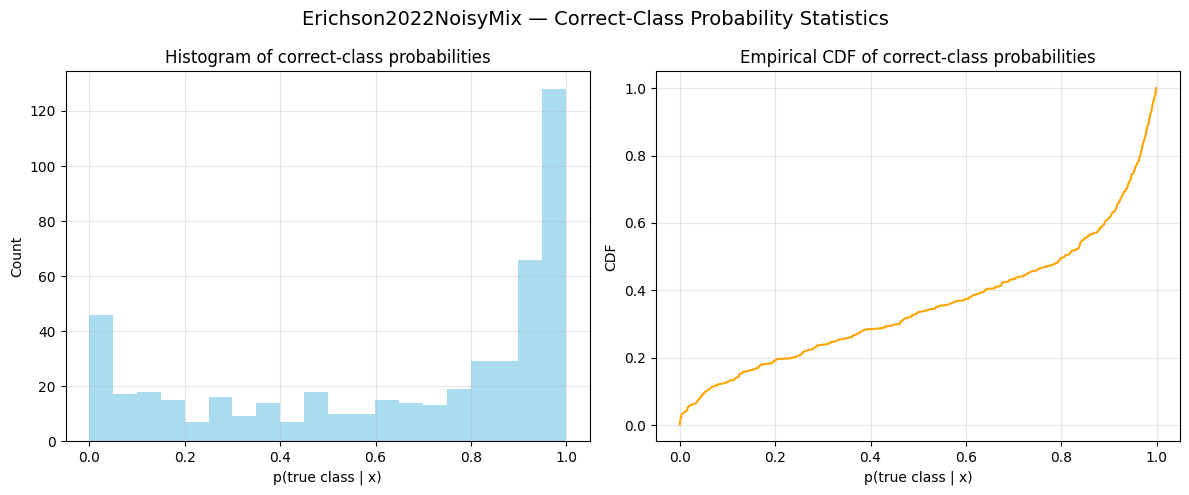


========== Evaluating model: Geirhos2018_SIN ==========
MSE: 0.370352
Accuracy: 63.00%


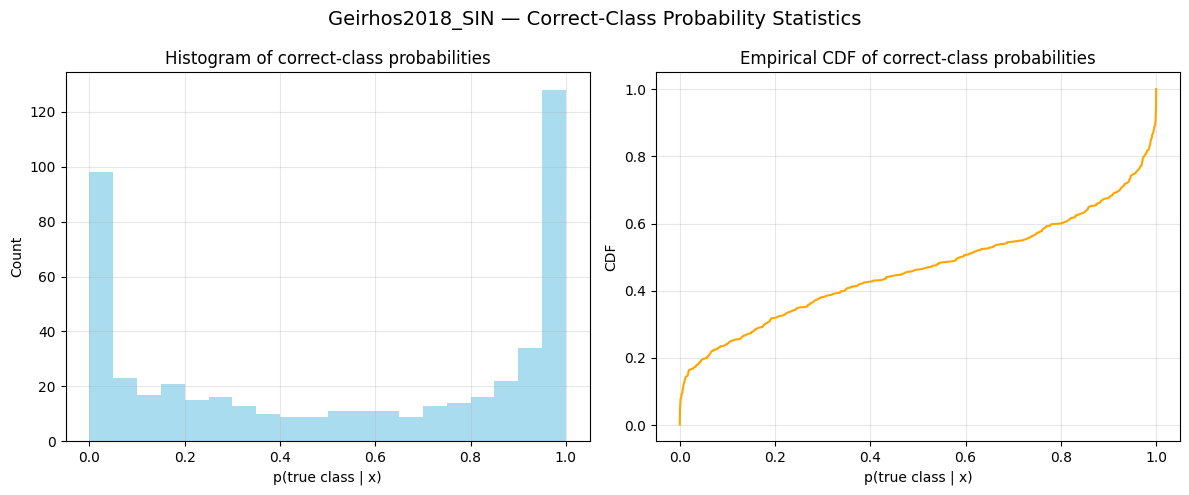

In [14]:
for name, model in models.items():
    print(f"\n========== Evaluating model: {name} ==========")
    probs, correct_probs, mse, acc = evaluate_model_probs(model, test_X, test_y, device)

    print(f"MSE: {mse:.6f}")
    print(f"Accuracy: {acc*100:.2f}%")

    # ----------------------------
    # Plots: Histogram + CDF
    # ----------------------------
    plt.figure(figsize=(12, 5))
    plt.suptitle(f"{name} — Correct-Class Probability Statistics", fontsize=14)

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(correct_probs.cpu().numpy(), bins=20, alpha=0.7, color='skyblue')
    plt.title("Histogram of correct-class probabilities")
    plt.xlabel("p(true class | x)")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # CDF
    plt.subplot(1, 2, 2)
    sorted_probs, _ = torch.sort(correct_probs.cpu())
    cdf = torch.arange(1, len(sorted_probs) + 1) / len(sorted_probs)

    plt.plot(sorted_probs.numpy(), cdf.numpy(), color='orange')
    plt.title("Empirical CDF of correct-class probabilities")
    plt.xlabel("p(true class | x)")
    plt.ylabel("CDF")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [15]:
# pip install torchattacks
import torchattacks
from autoattack import AutoAttack

class ProbToLogitsWrapper(torch.nn.Module):
    def __init__(self, model_prob):
        super().__init__()
        self.model_prob = model_prob  # il tuo modello che restituisce probabilità

    def forward(self, x):
        probs = self.model_prob(x)           # (B, K)
        logits = torch.log(probs + 1e-12)    # conversione sicura
        return logits

def attack_with_autoattack(model_prob, X, y, eps=8/255, norm='L2', bs=256, device='cuda'):
    model_prob.eval()

    # wrapper veloce
    model_for_attack = ProbToLogitsWrapper(model_prob).to(device)
    model_for_attack.eval()

    X = X.to(device)
    y = y.to(device)

    autoattack = AutoAttack(
        model_for_attack,
        norm=norm,
        eps=eps,
        version='custom',          # per avere un singolo attacco
        attacks_to_run=['apgd-ce'], 
        device=device,
        verbose=True
    )

    # riduci il numero di iterazioni
    autoattack.apgd.n_iter = 10
    
    adversarial_examples = autoattack.run_standard_evaluation(X, y, bs=bs)

    return adversarial_examples

In [16]:
eps = 0.5   # AutoAttack tipico
batch_size = 32

adv_data = {}  # qui salviamo i risultati per ogni modello

for model_name, model in models.items():
    print(f"\n========== Generating AutoAttack adversarial data for model: {model_name} ==========")

    # calibration set
    cal_X_adv = attack_with_autoattack(
        model, cal_X, cal_y,
        eps=eps,
        norm='L2',   # o 'Linf'
        bs=batch_size,
        device=device
    )

    # test set
    test_X_adv = attack_with_autoattack(
        model, test_X, test_y,
        eps=eps,
        norm='L2',
        bs=batch_size,
        device=device
    )

    adv_data[model_name] = {
        "cal_X_adv":  cal_X_adv,
        "test_X_adv": test_X_adv
    }

print("\nDone.")


========== Generating AutoAttack adversarial data for model: Xu2024MIMIR_Swin-L ==========
using custom version including apgd-ce.
initial accuracy: 83.00%
apgd-ce - 1/3 - 1 out of 32 successfully perturbed
apgd-ce - 2/3 - 2 out of 32 successfully perturbed
apgd-ce - 3/3 - 0 out of 19 successfully perturbed
robust accuracy after APGD-CE: 80.00% (total time 28.2 s)
max L2 perturbation: 0.50000, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 80.00%
using custom version including apgd-ce.
initial accuracy: 84.00%
apgd-ce - 1/3 - 2 out of 32 successfully perturbed
apgd-ce - 2/3 - 1 out of 32 successfully perturbed
apgd-ce - 3/3 - 1 out of 20 successfully perturbed
robust accuracy after APGD-CE: 80.00% (total time 28.4 s)
max L2 perturbation: 0.50000, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 80.00%

Done.


In [17]:
eps = 4/255   # AutoAttack tipico
batch_size = 32

adv_data = {}  # qui salviamo i risultati per ogni modello

for model_name, model in models.items():
    print(f"\n========== Generating AutoAttack adversarial data for model: {model_name} ==========")

    # calibration set
    cal_X_adv = attack_with_autoattack(
        model, cal_X, cal_y,
        eps=eps,
        norm='Linf',   # o 'Linf'
        bs=batch_size,
        device=device
    )

    # test set
    test_X_adv = attack_with_autoattack(
        model, test_X, test_y,
        eps=eps,
        norm='Linf',
        bs=batch_size,
        device=device
    )

    adv_data[model_name] = {
        "cal_X_adv":  cal_X_adv,
        "test_X_adv": test_X_adv
    }

print("\nDone.")


========== Generating AutoAttack adversarial data for model: Xu2024MIMIR_Swin-L ==========
using custom version including apgd-ce.
initial accuracy: 83.00%
apgd-ce - 1/3 - 12 out of 32 successfully perturbed
apgd-ce - 2/3 - 10 out of 32 successfully perturbed
apgd-ce - 3/3 - 3 out of 19 successfully perturbed
robust accuracy after APGD-CE: 58.00% (total time 21.6 s)
max Linf perturbation: 0.01569, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 58.00%
using custom version including apgd-ce.
initial accuracy: 84.00%
apgd-ce - 1/3 - 8 out of 32 successfully perturbed
apgd-ce - 2/3 - 8 out of 32 successfully perturbed
apgd-ce - 3/3 - 6 out of 20 successfully perturbed
robust accuracy after APGD-CE: 62.00% (total time 22.6 s)
max Linf perturbation: 0.01569, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 62.00%

Done.



========== Post-attack evaluation for model: Erichson2022NoisyMix ==========
MSE (clean): 0.209696
MSE after attack: 0.331369
Accuracy (clean): 80.00%
Accuracy after attack: 60.00%


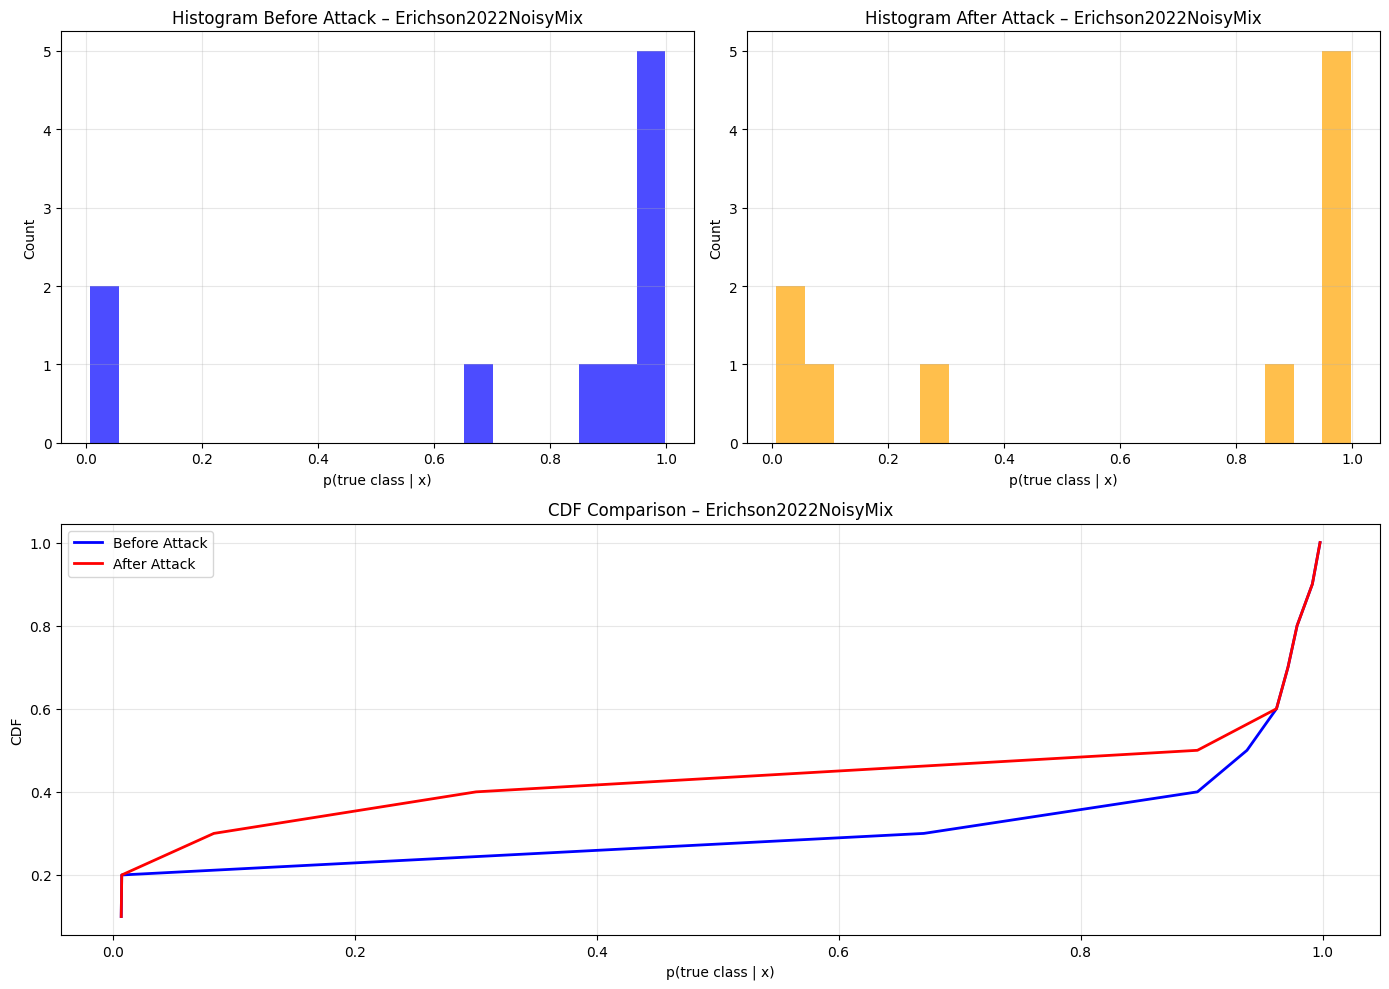

In [33]:
batch_size = 128

results_post_attack = {}

for model_name, model in models.items():
    print(f"\n========== Post-attack evaluation for model: {model_name} ==========")

    model.eval()
    test_X_adv = adv_data[model_name]["test_X_adv"]

    # -----------------------------
    # Forward pass adversarial
    # -----------------------------
    all_probs_adv = []
    with torch.no_grad():
        for i in range(0, len(test_X_adv), batch_size):
            batch = test_X_adv[i:i+batch_size].to(device)
            p = model(batch)
            all_probs_adv.append(p)

    probs_adv = torch.cat(all_probs_adv, dim=0)

    # -----------------------------
    # Pre-attack probs (calcoliamole se non le hai salvate)
    # -----------------------------
    all_probs_clean = []
    with torch.no_grad():
        for i in range(0, len(test_X), batch_size):
            batch = test_X[i:i+batch_size].to(device)
            p = model(batch)
            all_probs_clean.append(p)

    probs_clean = torch.cat(all_probs_clean, dim=0)

    # Correct class probabilities
    correct_probs_clean = probs_clean[range(len(test_y)), test_y]
    correct_probs_adv   = probs_adv[range(len(test_y)), test_y]

    # -----------------------------
    # MSE
    # -----------------------------
    mse_adv = ((correct_probs_adv - 1)**2).mean().item()
    mse_clean = ((correct_probs_clean - 1)**2).mean().item()

    print(f"MSE (clean): {mse_clean:.6f}")
    print(f"MSE after attack: {mse_adv:.6f}")

    # -----------------------------
    # Accuracy
    # -----------------------------
    preds_clean = probs_clean.argmax(dim=1)
    preds_adv   = probs_adv.argmax(dim=1)

    acc_clean = (preds_clean == test_y.to(device)).float().mean().item()
    acc_adv   = (preds_adv == test_y.to(device)).float().mean().item()

    print(f"Accuracy (clean): {acc_clean*100:.2f}%")
    print(f"Accuracy after attack: {acc_adv*100:.2f}%")

    # -----------------------------
    # Pre and Post Attack CDFs
    # -----------------------------
    sorted_probs_pre  = np.sort(correct_probs_clean.cpu().numpy())
    sorted_probs_post = np.sort(correct_probs_adv.cpu().numpy())

    cdf_pre  = np.arange(1, len(sorted_probs_pre)+1)  / len(sorted_probs_pre)
    cdf_post = np.arange(1, len(sorted_probs_post)+1) / len(sorted_probs_post)

    # -----------------------------
    # PLOT
    # -----------------------------
    fig = plt.figure(figsize=(14, 10))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1])

    # Histogram before
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.hist(correct_probs_clean.cpu().numpy(), bins=20, alpha=0.7, color='blue')
    ax0.set_title(f"Histogram Before Attack – {model_name}")
    ax0.set_xlabel("p(true class | x)")
    ax0.set_ylabel("Count")
    ax0.grid(alpha=0.3)

    # Histogram after
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.hist(correct_probs_adv.cpu().numpy(), bins=20, alpha=0.7, color='orange')
    ax1.set_title(f"Histogram After Attack – {model_name}")
    ax1.set_xlabel("p(true class | x)")
    ax1.set_ylabel("Count")
    ax1.grid(alpha=0.3)

    # CDF comparison
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(sorted_probs_pre, cdf_pre, color='blue', linewidth=2, label='Before Attack')
    ax2.plot(sorted_probs_post, cdf_post, color='red',  linewidth=2, label='After Attack')
    ax2.set_title(f"CDF Comparison – {model_name}")
    ax2.set_xlabel("p(true class | x)")
    ax2.set_ylabel("CDF")
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Save results
    results_post_attack[model_name] = {
        "mse_clean": mse_clean,
        "mse_adv": mse_adv,
        "acc_clean": acc_clean,
        "acc_adv": acc_adv,
        "correct_probs_clean": correct_probs_clean,
        "correct_probs_adv": correct_probs_adv,
    }


In [18]:
def nonconformity_score(y_true, y_pred, u=None):
    """
    Compute nonconformity scores for regression CP, optionally using an uncertainty scalar.

    Args:
        y_true: torch.Tensor of shape (n,)  -- true regression targets
        y_pred: torch.Tensor of shape (n,)  -- predicted regression outputs
        u: torch.Tensor of shape (n,), optional -- per-example uncertainty (e.g., predicted std or residual)
    
    Returns:
        scores: torch.Tensor of shape (n,)  -- nonconformity scores
    """
    residuals = torch.abs(y_pred - y_true)
    
    if u is not None:
        scores = residuals / u
        
    else:
        scores = residuals
    
    return scores

def cp_interval_width(u, qhat):
    """
    Computes conformal prediction interval widths.
    
    Args:
        u:    array-like of shape (n,) -- uncertainty scalar u(x)
        qhat: float                   -- conformal quantile

    Returns:
        width: array of shape (n,) -- interval widths
    """
    u = torch.as_tensor(u, dtype=torch.float32)
    return 2 * u * qhat

def extract_scores(models,
                   cal_X, cal_y,
                   test_X, test_y,
                   datamode="clean"):
    """
    Estrarre score, predizioni e u dal calibration e test set.
    Può lavorare sia su dati clean sia attaccati.

    Args:
        models: dict {name: model}
        cal_X, cal_y: calibration data
        test_X, test_y: test data
        datamode: "clean" oppure "adv"

    Returns:
        results: dict con per-modello:
            probs_cal, y_pred_cal, u_cal, score_cal
            probs_test, y_pred_test, u_test, score_test
    """

    results = {}

    with torch.no_grad():
        for name, model in models.items():
            print(f"\n=== Processing model: {name} ({datamode}) ===")

            # -----------------------------
            # Calibrazione
            # -----------------------------
            probs_cal = model(cal_X)
            y_pred_cal = probs_cal[range(len(cal_y)), cal_y]

            #u_cal = ((y_pred_cal - 1) ** 2)#.mean().item()
            #epsilon = 1e-6
            #u_cal = torch.sqrt((y_pred_cal - 1) ** 2 + epsilon)
            
            residuals = torch.abs(y_pred_cal - 1)  # shape (n_cal,)
            residuals_reshaped = residuals.unsqueeze(0).unsqueeze(0)  # shape (1,1,n_cal)

            # Apply a 1D average pooling with kernel size 5
            smoothed_residuals = F.avg_pool1d(residuals_reshaped, kernel_size=5, stride=1, padding=2)
            u_cal = smoothed_residuals.squeeze()
            
            score_cal = nonconformity_score(
                1.0,
                y_pred_cal.float(),
                u=u_cal
            )

            # -----------------------------
            # Test
            # -----------------------------
            probs_test = model(test_X)
            y_pred_test = probs_test[range(len(test_y)), test_y]

            #u_test = ((y_pred_test - 1) ** 2)#.mean().item()
            #u_test = torch.sqrt((y_pred_test - 1) ** 2 + epsilon)
            residuals = torch.abs(y_pred_test - 1)  # shape (n_cal,)
            residuals_reshaped = residuals.unsqueeze(0).unsqueeze(0)  # shape (1,1,n_cal)

            # Apply a 1D average pooling with kernel size 5
            smoothed_residuals = F.avg_pool1d(residuals_reshaped, kernel_size=5, stride=1, padding=2)
            u_test = smoothed_residuals.squeeze()
            
            score_test = nonconformity_score(
                1.0,
                y_pred_test.float(),
                u=u_test
            )

            # -----------------------------
            # Salvataggio
            # -----------------------------
            results[name] = {
                "probs_cal": probs_cal,
                "y_pred_cal": y_pred_cal,
                "u_cal": u_cal,
                "score_cal": score_cal,

                "probs_test": probs_test,
                "y_pred_test": y_pred_test,
                "u_test": u_test,
                "score_test": score_test,
            }

    return results


In [19]:
def plot_scores_for_all_models(results):
    
    for name, data in results.items():
        print(f"\n=== Plotting for model: {name} ===")
        
        score_cal = data["score_cal"]
        score_test = data["score_test"]

        # Convert to numpy
        score_cal_np = score_cal.cpu().numpy() if hasattr(score_cal, "cpu") else np.array(score_cal)
        score_test_np = score_test.cpu().numpy() if hasattr(score_test, "cpu") else np.array(score_test)

        # Create figure
        plt.figure(figsize=(16, 5))
        plt.suptitle(f"Nonconformity Scores – {name}", fontsize=16)

        # -------------------------
        # 1. Histogram
        # -------------------------
        plt.subplot(1, 3, 1)
        plt.hist(score_cal_np, bins=30, alpha=0.6, label="Calibration", color='blue')
        plt.hist(score_test_np, bins=30, alpha=0.6, label="Test", color='orange')
        plt.title("Histogram of Scores")
        plt.xlabel("Score")
        plt.ylabel("Frequency")
        plt.legend()

        # -------------------------
        # 2. Boxplot
        # -------------------------
        plt.subplot(1, 3, 2)
        plt.boxplot([score_cal_np, score_test_np], labels=["Calibration", "Test"])
        plt.title("Boxplot of Scores")
        plt.ylabel("Score")

        # -------------------------
        # 3. Empirical CDF
        # -------------------------
        plt.subplot(1, 3, 3)
        sorted_cal = np.sort(score_cal_np)
        sorted_test = np.sort(score_test_np)
        cdf_cal = np.arange(1, len(sorted_cal)+1) / len(sorted_cal)
        cdf_test = np.arange(1, len(sorted_test)+1) / len(sorted_test)

        plt.plot(sorted_cal, cdf_cal, label="Calibration", color='blue', linewidth=2)
        plt.plot(sorted_test, cdf_test, label="Test", color='orange', linewidth=2)

        plt.title("Empirical CDF of Scores")
        plt.xlabel("Score")
        plt.ylabel("CDF")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.tight_layout()
        plt.show()


In [20]:
def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)

In [21]:
def compute_cp(
    clean_results, 
    adv_results, 
    alpha=0.1, 
    cal_on='clean',     # calibrazione su 'clean' o 'adv'
    eval_on='clean',    # dataset su cui calcolare coverage
    interval_on='test'  # 'test' oppure 'cal'
):
    """
    Calcola CP in modo flessibile.

    clean_results: dizionario score clean
    adv_results:   dizionario score avversari
    cal_on:        set per calibrazione ('clean' o 'adv')
    eval_on:       set per coverage ('clean' o 'adv')
    interval_on:   set su cui costruire gli intervalli ('cal' o 'test')
    """
    
    cp_outputs = {}
    
    for name in clean_results.keys():
        print(f"\n--- CP for model: {name} | Cal: {cal_on} | Eval: {eval_on} | Interval: {interval_on} ---")
        
        clean = clean_results[name]
        adv   = adv_results[name]

        # -------------------------
        # STEP 1 — Calibrazione
        # -------------------------
        source_cal = clean if cal_on=='clean' else adv

        score_cal = _to_numpy(source_cal["score_cal"])
        y_pred_cal = _to_numpy(source_cal["y_pred_cal"]).astype(np.float32)
        u_cal = _to_numpy(source_cal["u_cal"])

        n_cal = len(score_cal)
        q_level = np.floor((n_cal + 1) * (1 - alpha)) / n_cal
        qhat = float(
            torch.quantile(torch.tensor(score_cal, dtype=torch.float32), float(q_level))
        )

        print(f" q̂ (CP): {qhat:.6f}")

        # -------------------------
        # STEP 2 — Scegli set per intervalli
        # -------------------------
        if interval_on == 'test':
            y_pred_interval = clean["y_pred_test"] if eval_on=='clean' else adv["y_pred_test"]
            u_interval      = clean["u_test"]      if cal_on=='clean' else adv["u_test"]
        elif interval_on == 'cal':
            y_pred_interval = clean["y_pred_cal"] if eval_on=='clean' else adv["y_pred_cal"]
            u_interval      = clean["u_cal"]      if cal_on=='clean' else adv["u_cal"]
        else:
            raise ValueError("interval_on must be 'cal' or 'test'")
        
        
        y_pred_eval = _to_numpy(y_pred_interval).astype(np.float32)
        u_eval      = _to_numpy(u_interval)
                
        # -------------------------
        # STEP 3 — Coverage (sempre sul test o cal, deciso da eval_on)
        # -------------------------

        y_true_eval = np.ones_like(y_pred_eval, dtype=np.float32)

        # -------------------------
        # STEP 4 — Costruisci intervalli
        # -------------------------
        radius = qhat * u_eval
        lower  = y_pred_eval - radius
        upper  = y_pred_eval + radius

        coverage = float(np.mean((lower <= y_true_eval) & (y_true_eval <= upper)))
        mean_width = float(np.mean(upper - lower))

        print(f" Coverage: {coverage*100:.2f}%")
        print(f" Mean interval width: {mean_width:.6f}")

        cp_outputs[name] = {
            "qhat": qhat,
            "coverage": coverage,
            "mean_width": mean_width,
            "lower": lower,
            "upper": upper,
            "y_pred_interval": y_pred_interval,
            "u_interval": u_interval,
            "cal_on": cal_on,
            "eval_on": eval_on,
            "interval_on": interval_on,
        }

    return cp_outputs


In [22]:
clean_results = extract_scores(
    models,
    cal_X, cal_y,
    test_X, test_y,
    datamode="clean"
)


=== Processing model: Xu2024MIMIR_Swin-L (clean) ===



=== Plotting for model: Erichson2022NoisyMix ===


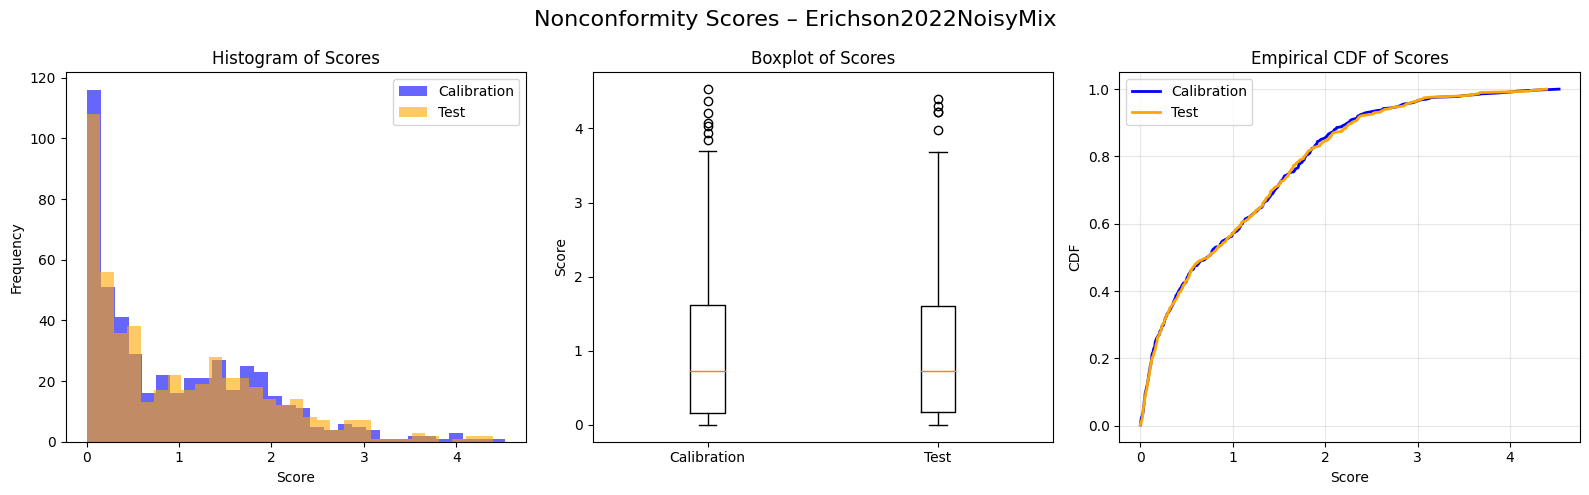


=== Plotting for model: Geirhos2018_SIN ===


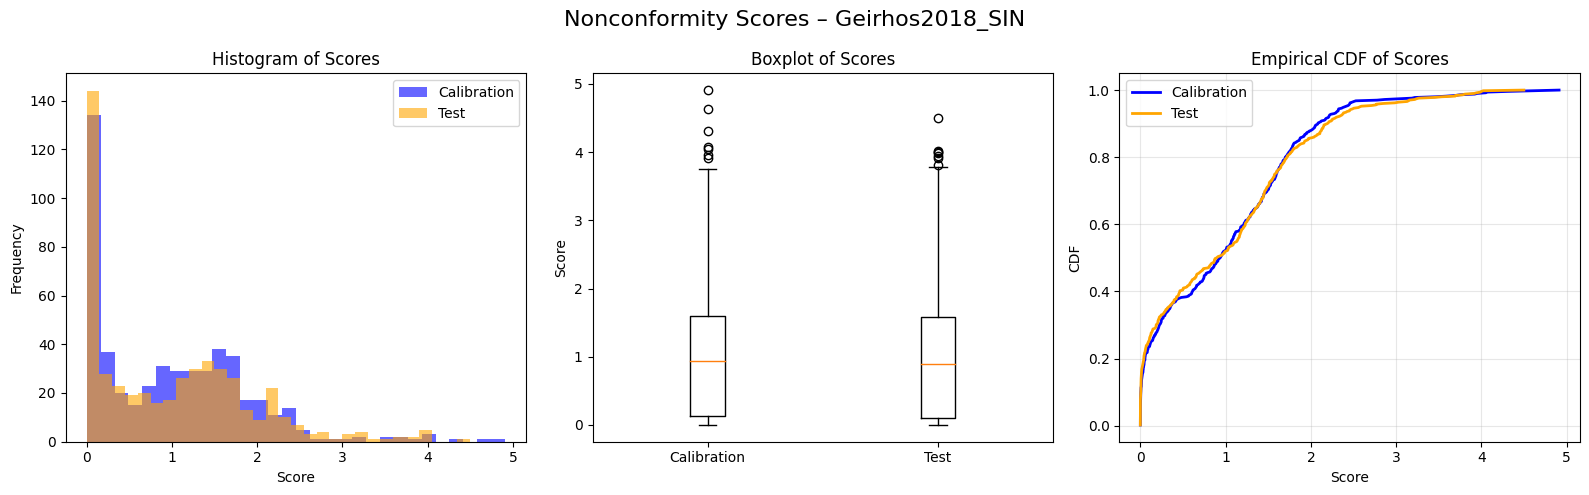

In [20]:
plot_scores_for_all_models(clean_results)

In [23]:
adv_results = extract_scores(
    models,
    cal_X_adv, cal_y,
    test_X_adv, test_y,
    datamode="adv"
)


=== Processing model: Xu2024MIMIR_Swin-L (adv) ===



=== Plotting for model: Erichson2022NoisyMix ===


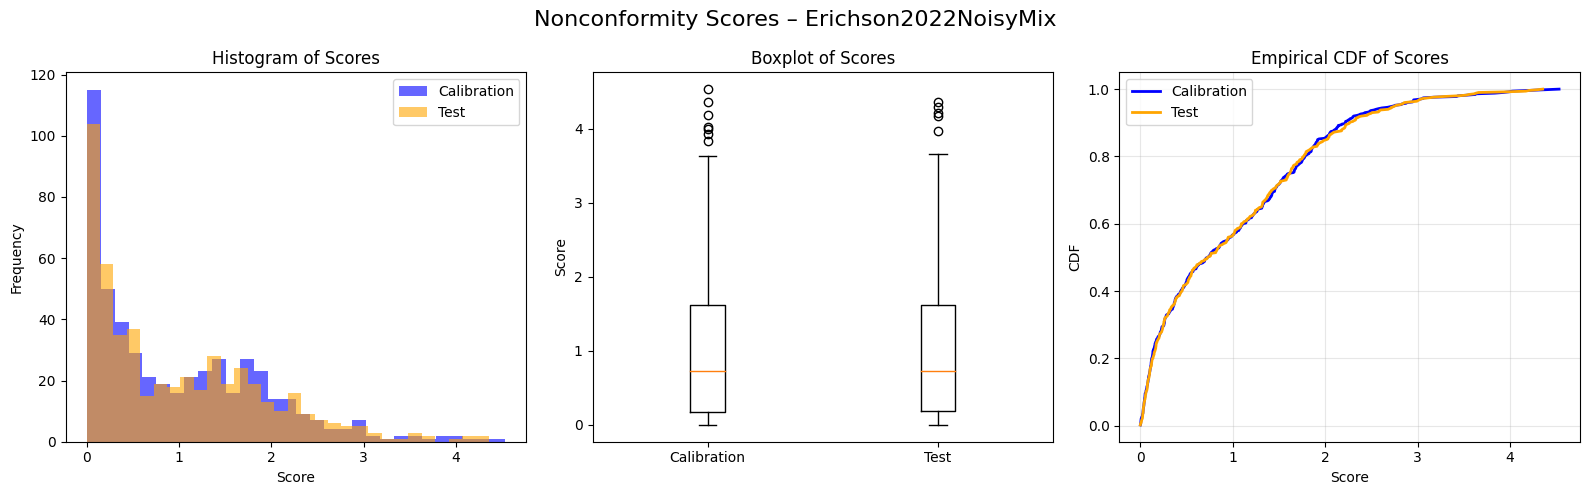


=== Plotting for model: Geirhos2018_SIN ===


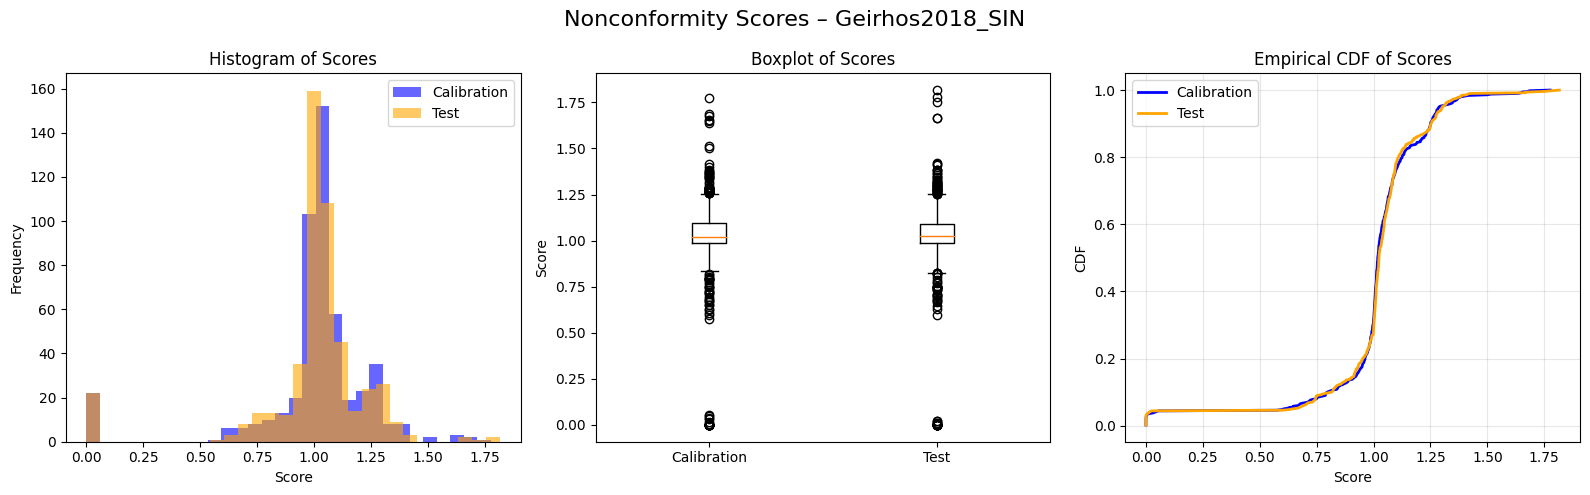

In [22]:
plot_scores_for_all_models(adv_results)

In [24]:
vanilla_cp_test = compute_cp(clean_results, adv_results, alpha=0.1, cal_on='clean', eval_on='adv', interval_on='test' )
adv_cp_test = compute_cp(clean_results, adv_results, alpha=0.1,cal_on='adv', eval_on='adv', interval_on='test')


--- CP for model: Xu2024MIMIR_Swin-L | Cal: clean | Eval: adv | Interval: test ---
 q̂ (CP): 1.793255
 Coverage: 78.00%
 Mean interval width: 1.421360

--- CP for model: Xu2024MIMIR_Swin-L | Cal: adv | Eval: adv | Interval: test ---
 q̂ (CP): 1.891072
 Coverage: 89.00%
 Mean interval width: 1.770838


In [24]:
vanilla_cp_cal = compute_cp(clean_results, adv_results, alpha=0.1, cal_on='clean', eval_on='adv', interval_on='cal' )
adv_cp_cal = compute_cp(clean_results, adv_results, alpha=0.1,cal_on='adv', eval_on='adv', interval_on='cal')



--- CP for model: Erichson2022NoisyMix | Cal: clean | Eval: adv | Interval: cal ---
 q̂ (CP): 2.246444
 Coverage: 89.60%
 Mean interval width: 1.640863

--- CP for model: Geirhos2018_SIN | Cal: clean | Eval: adv | Interval: cal ---
 q̂ (CP): 2.082478
 Coverage: 58.40%
 Mean interval width: 2.034518

--- CP for model: Erichson2022NoisyMix | Cal: adv | Eval: adv | Interval: cal ---
 q̂ (CP): 2.219410
 Coverage: 90.00%
 Mean interval width: 1.640275

--- CP for model: Geirhos2018_SIN | Cal: adv | Eval: adv | Interval: cal ---
 q̂ (CP): 1.250692
 Coverage: 90.00%
 Mean interval width: 2.262407
